In [ ]:
"""
TO DO
> verify if better to save functions outside this script as .py to run it with .bat and Windows Scheduler
> modify way to compute on/off times (off = round((total - on)/on))
> verify configparser on UIT
> clean it before one-take script run
"""

In [12]:
import pandas as pd
import configparser
import pylab as pl
import os
from datetime import datetime, timedelta
import shutil

import matplotlib.pyplot as plt

In [2]:
#Define a function to load R2 files
def get_directory_path(reactor):
    # Replace 'base_directory' with the base directory path where your CSV files are stored
    base_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/'
    
    # Create a subdirectory name based on the 'i' index
    subdirectory_name = reactor
    
    # Combine the base directory and subdirectory to get the full path
    full_directory_path = os.path.join(base_directory, subdirectory_name)
    # Replace backslashes with forward slashes
    full_directory_path = full_directory_path.replace('\\', '/')
    
    return full_directory_path
reactor_number = 2
reactor = f'R{reactor_number}'
print(get_directory_path(reactor))

C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/R2


In [6]:
# Loop through the dates in the specified range and read the corresponding .csv files
# Get the current date and the previous date

current_date = datetime.now().strftime('%Y-%m-%d')
previous_date = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')


#Alternative specifying data
#start_date = datetime(2024, 1, 15)  # Start date in the format: YYYY, MM, DD
#current_date = start_date.strftime('%Y-%m-%d')
#previous_date = (start_date - timedelta(days=1)).strftime('%Y-%m-%d')

def read(date,reactor):
    directory_path = get_directory_path(reactor)
    file_path = os.path.join(directory_path, f'{date}_{reactor}.csv')  # Join directory path with file name
    file_path = file_path.replace('\\', '/')

    try:
        # Read the .csv file and append the dataframe to the list
        df = pd.read_csv(file_path,encoding='ISO-8859-1',delimiter = ';', 
                   parse_dates=['Timestamp'], dayfirst=True)
        print(f"Successfully read {date}_{reactor}")
        return df
    except FileNotFoundError:
        print(f"File {date} not found at path {file_path}.")

today = read(current_date,reactor)
yesterday = read(previous_date,reactor)

# Concatenate all the dataframes into one
#combined_dataframe = pd.concat([today,yesterday], ignore_index=True)
combined_dataframe = pd.concat([yesterday,today], ignore_index=True)

Successfully read 2024-01-25_R2
Successfully read 2024-01-24_R2


In [9]:
mean_R2 = combined_dataframe['2F1.1 [L/h]'].mean()
stdev_R2 = combined_dataframe['2F1.1 [L/h]'].std()
print(mean_R2,stdev_R2)

0.6749288425047438 1.3476407145994516


In [10]:
#OUTLIER DETECTION AND REPLACEMENT
#Z-score method: average and st.dev. calculated with respect to the overall time series 
#or with respect to the sliding window?
import numpy as np

rate = f'{reactor_number}F1.1 [L/h]'
ch4 = f'{reactor_number}X11Q3 [V% CH4]'
co2 = f'{reactor_number}X11Q2 [V% CO2]'
if rate and ch4 and co2 in combined_dataframe.columns:

    combined_dataframe['Z-score_rate'] = np.abs((combined_dataframe[rate] - combined_dataframe[rate].mean()) / combined_dataframe[rate].std())
    combined_dataframe['Z-score_ch4'] = np.abs((combined_dataframe[ch4] - combined_dataframe[ch4].mean()) / combined_dataframe[ch4].std())
    combined_dataframe['Z-score_co2'] = np.abs((combined_dataframe[co2] - combined_dataframe[co2].mean()) / combined_dataframe[co2].std())
    # Replace outliers with the mean of the closest previous and next neighbors
    threshold = 6  # Define your threshold for Z-score
    # Find indices of outliers
    outlier_indices_rate = np.where(combined_dataframe['Z-score_rate'] > threshold)[0]
    outlier_indices_ch4 = np.where(combined_dataframe['Z-score_ch4'] > threshold)[0]
    outlier_indices_co2 = np.where(combined_dataframe['Z-score_co2'] > threshold)[0]
    #combined_dataframe['2F1.1 [L/h]_out'] = np.where(combined_dataframe['Z-score'] > threshold, combined_dataframe['2F1.1 [L/h]'].rolling(window=50, min_periods=1, center=True).mean(), combined_dataframe['2F1.1 [L/h]'])

    # Drop the 'Z-score' column if no longer needed
    #combined_dataframe = combined_dataframe.drop('Z-score', axis=1)

    # Create a new column 'interpolated_data' with the original data
    combined_dataframe[f'{reactor_number}F1.1 [L/h]_out'] = combined_dataframe[rate]
    combined_dataframe[f'{reactor_number}X11Q3 [V% CH4]_out'] = combined_dataframe[ch4]
    combined_dataframe[f'{reactor_number}X11Q2 [V% CO2]_out'] = combined_dataframe[co2]

    # Replace outliers with linear interpolation
    interpolated_values_list_rate = []
    interpolated_values_list_ch4 = []
    interpolated_values_list_co2 = []
    #for idx in outlier_indices:
    #    if 0 < idx < len(combined_dataframe) - 1 and idx not in outlier_indices:
    #        prev_valid_idx = combined_dataframe['2F1.1 [L/h]_out'].index[combined_dataframe['2F1.1 [L/h]_out'].iloc[:idx].notnull()].max()
    #        next_valid_idx = combined_dataframe['2F1.1 [L/h]_out'].index[combined_dataframe['2F1.1 [L/h]_out'].iloc[idx:].notnull()].min()
    #        if prev_valid_idx is not pd.NA and next_valid_idx is not pd.NA:
    #            prev_value = combined_dataframe.at[prev_valid_idx, '2F1.1 [L/h]_out']
    #            next_value = combined_dataframe.at[next_valid_idx, '2F1.1 [L/h]_out']
    #            interpolated_value = prev_value + (next_value - prev_value) / (next_valid_idx - prev_valid_idx).days * (idx - prev_valid_idx).days
    #            interpolated_values_list.append = interpolated_value
    #            combined_dataframe.at[idx, '2F1.1 [L/h]_out'] = interpolated_value

    for idx in outlier_indices_rate:
        prev_idx = idx-1
        while prev_idx in outlier_indices_rate:
            prev_idx = prev_idx-1
        next_idx = idx+1
        while next_idx in outlier_indices_rate:
            next_idx = next_idx+1
        interpolated_value = combined_dataframe.at[prev_idx, f'{reactor_number}F1.1 [L/h]_out'] + ((idx - prev_idx) * (combined_dataframe.at[next_idx, f'{reactor_number}F1.1 [L/h]_out'] - combined_dataframe.at[prev_idx, f'{reactor_number}F1.1 [L/h]_out'])) / (next_idx - prev_idx)
        interpolated_values_list_rate.append(prev_idx)
        combined_dataframe.at[idx, f'{reactor_number}F1.1 [L/h]_out'] = interpolated_value

    for idx in outlier_indices_ch4:
        prev_idx = idx-1
        while prev_idx in outlier_indices_ch4:
            prev_idx = prev_idx-1
        next_idx = idx+1
        while next_idx in outlier_indices_ch4:
            next_idx = next_idx+1
        interpolated_value = combined_dataframe.at[prev_idx, f'{reactor_number}X11Q3 [V% CH4]_out'] + ((idx - prev_idx) * (combined_dataframe.at[next_idx, f'{reactor_number}X11Q3 [V% CH4]_out'] - combined_dataframe.at[prev_idx, f'{reactor_number}X11Q3 [V% CH4]_out'])) / (next_idx - prev_idx)
        interpolated_values_list_ch4.append(prev_idx)
        combined_dataframe.at[idx, f'{reactor_number}X11Q3 [V% CH4]_out'] = interpolated_value

    for idx in outlier_indices_co2:
        prev_idx = idx-1
        while prev_idx in outlier_indices_co2:
            prev_idx = prev_idx-1
        next_idx = idx+1
        while next_idx in outlier_indices_co2:
            next_idx = next_idx+1
        interpolated_value = combined_dataframe.at[prev_idx, f'{reactor_number}X11Q2 [V% CO2]_out'] + ((idx - prev_idx) * (combined_dataframe.at[next_idx, f'{reactor_number}X11Q2 [V% CO2]_out'] - combined_dataframe.at[prev_idx, f'{reactor_number}X11Q2 [V% CO2]_out'])) / (next_idx - prev_idx)
        interpolated_values_list_co2.append(prev_idx)
        combined_dataframe.at[idx, f'{reactor_number}X11Q2 [V% CO2]_out'] = interpolated_value

    # Updated time series data with outliers replaced by interpolated values
    updated_time_series_rate = combined_dataframe[f'{reactor_number}F1.1 [L/h]_out']
    updated_time_series_ch4 = combined_dataframe[f'{reactor_number}X11Q3 [V% CH4]_out']
    updated_time_series_co2 = combined_dataframe[f'{reactor_number}X11Q2 [V% CO2]_out']

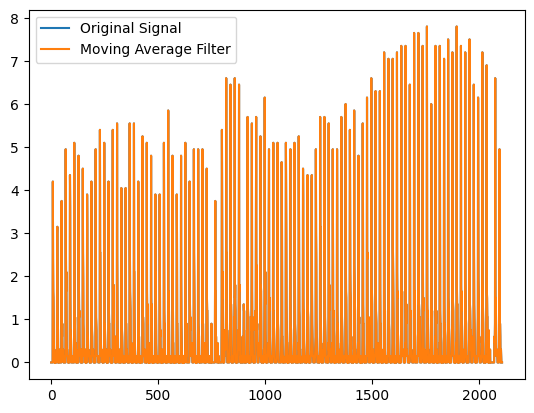

In [14]:
plt.plot(combined_dataframe['2F1.1 [L/h]'], label='Original Signal')
plt.plot(combined_dataframe['2F1.1 [L/h]_out'], label=f'Moving Average Filter')
#plt.plot(combined_dataframe['gas_ratio'], label='Original Signal')
#plt.plot(combined_dataframe['filtered_ratio'], label=f'Moving Average Filter (window_size={window_size})')
ax = plt.gca()
#ax.set_ylim([0, 2])
#ax.set_xlim([500, 800])
plt.legend()
plt.show()

In [15]:
rate = f'{reactor_number}F1.1 [L/h]_out'
ch4 = f'{reactor_number}X11Q3 [V% CH4]_out'
co2 = f'{reactor_number}X11Q2 [V% CO2]_out'
combined_dataframe['ch4_rate'] = combined_dataframe[rate]*combined_dataframe[ch4]/100
# Identify rows where 'co2' column is 0
zero_value_rows = combined_dataframe[combined_dataframe[co2] == 0]
# Print the corresponding 'timestamp' values
print("Timestamps corresponding to rows with 'co2' = 0:")
print(zero_value_rows['Timestamp'].tolist())
combined_dataframe['gas_ratio'] = np.where(combined_dataframe[co2] == 0, 0, combined_dataframe[ch4]/combined_dataframe[co2])

Timestamps corresponding to rows with 'co2' = 0:
[]


In [27]:
#Moving average filter
def moving_average_filter(signal, window_size):
    kernel = np.ones(window_size) / window_size
    filtered_signal = convolve(signal, kernel, mode='valid')
    return np.concatenate((np.full(window_size - 1, np.nan), filtered_signal), axis=0)

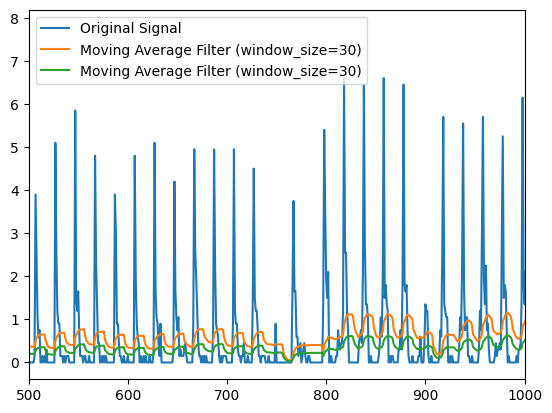

In [23]:
import numpy as np
from scipy.signal import convolve
window_size = 30

# Apply the moving average filter to the 'value' column
combined_dataframe['filtered_gas_rate'] = moving_average_filter(combined_dataframe[rate], window_size)
combined_dataframe['filtered_ch4_rate'] = moving_average_filter(combined_dataframe['ch4_rate'], window_size)
combined_dataframe['filtered_ratio'] = moving_average_filter(combined_dataframe['gas_ratio'], window_size)
combined_dataframe['filtered_gasrateoriginal'] = moving_average_filter(combined_dataframe['2F1.1 [L/h]'], window_size)

# Plotting the results
plt.plot(combined_dataframe['2F1.1 [L/h]'], label='Original Signal')
plt.plot(combined_dataframe['filtered_gasrateoriginal'], label=f'Moving Average Filter (window_size={window_size})')
#plt.plot(combined_dataframe['2F1.1 [L/h]_out'], label='Original Signal')
plt.plot(combined_dataframe['filtered_rate'], label=f'Moving Average Filter (window_size={window_size})')
#plt.plot(combined_dataframe['gas_ratio'], label='Original Signal')
#plt.plot(combined_dataframe['filtered_ratio'], label=f'Moving Average Filter (window_size={window_size})')
ax = plt.gca()
#ax.set_ylim([0, 2])
ax.set_xlim([500, 1000])
plt.legend()
plt.show()

In [31]:
print(combined_dataframe)

               Timestamp  2T1 [°C]  2Q1 [pH]  2S1 [1/min]  2X1 [Ncm]  \
0    2024-01-24 00:00:22     42.57      7.46          0.0        0.0   
1    2024-01-24 00:01:22     42.57      7.46          0.0        0.0   
2    2024-01-24 00:02:22     42.57      7.45          0.0        0.0   
3    2024-01-24 00:03:22     42.58      7.45          0.0        0.0   
4    2024-01-24 00:04:22     42.56      7.46          0.0        0.0   
...                  ...       ...       ...          ...        ...   
2103 2024-01-25 11:07:39     42.36      7.41          0.0        0.0   
2104 2024-01-25 11:08:39     42.36      7.41          0.0        0.0   
2105 2024-01-25 11:09:39     42.35      7.41          0.0        0.0   
2106 2024-01-25 11:10:39     42.35      7.40          0.0        0.0   
2107 2024-01-25 11:11:40     42.35      7.41          0.0        0.0   

      2T4 [°C]  2F1.1 [L/h]  2F1.2 [L]  2X11F1 [L]  2X11Q1 [V% O2]  ...  \
0         44.1         0.00     251.14        0.00          

In [24]:
current_date = datetime.now().strftime('%Y-%m-%d')
# Format the date as a string
log_date = current_date

In [46]:
#PI controller with saturation
#Choice to saturate the integral term or not
#Add on/off condition in the log!!
class PIController:
    def __init__(self, name, kp, ki, saturation_low=None, saturation_high=None, saturate_integral=True):
        self.name = name
        self.kp = kp
        self.ki = ki
        self.saturation_low = saturation_low
        self.saturation_high = saturation_high
        self.saturate_integral = saturate_integral
        self.log_df = pd.DataFrame(columns=['timestamp', 'error', 'integral','integral_past','u_p','u_i','u_i_past','control_signal','saturation','selection'])

    def compute(self, error, dt, selection):
        #error = setpoint - feedback

        # Integral term
        integral_past = self.log_df['integral'].iloc[-1] if not self.log_df.empty else 0 #if not, assert?
        integral = integral_past + error * dt

        # Apply saturation to the integral term if specified
        if self.saturate_integral:
            if self.saturation_low is not None and integral < self.saturation_low:
                integral = self.saturation_low
            elif self.saturation_high is not None and integral > self.saturation_high:
                integral = self.saturation_high

        # Calculate the control signal (output)
        #I need to add the time interval in the integral part!
        # ADD antiwindup!!
        u_p = self.kp * error
        u_i_past = self.ki*integral_past #Just for checking purposes. Must always be 'control_signal - u_p' at the previous iteration
        u_i = self.ki * integral
        control_signal = u_p + u_i

        # Apply saturation to the control signal
        if self.saturation_low is not None and control_signal < self.saturation_low:
            control_signal = self.saturation_low
        elif self.saturation_high is not None and control_signal > self.saturation_high:
            control_signal = self.saturation_high
            
        # If saturation, apply anti-windup
        if control_signal <= self.saturation_low:
            saturation = 'Low'
            integral = (control_signal - u_p)/self.ki
        elif control_signal >= self.saturation_high:
            saturation = 'High'
            integral = (control_signal - u_p)/self.ki
        else:
            saturation = 'No'

        # Log the values
        timestamp = datetime.now()
        self.log_df = self.log_df.append({'timestamp': timestamp, 'error': error, 'integral': integral,'integral_past': integral_past,'u_p':u_p,'u_i':u_i,'u_i_past':u_i_past,
                                          'control_signal':control_signal,'saturation':saturation,'selection': selection}, ignore_index=True)
        
        return control_signal
    
    def reset_state(self, desired_value):
        # Reset the state by appending a new row with the desired value ??
        timestamp = datetime.now()
        new_row = {'timestamp': timestamp, 'error': '-', 'integral': desired_value,'control_signal':'-','selection': str('reselected')}
        self.log_df = self.log_df.append(new_row, ignore_index=True)
    
    def save_state(self, filename=None):
        # If filename is not provided, use a default filename based on the controller's name
        if filename is None:
            filename = f"{self.name}_{log_date}_state.csv"
        
        # Save the log_df DataFrame to a file
        self.log_df.to_csv(filename, index=False)

    def load_state(self, filename=None):
        # If filename is not provided, use a default filename based on the controller's name
        if filename is None:
            filename = f"{self.name}_{log_date}_state.csv"
        
        # Load the log_df DataFrame from a file
        try:
            self.log_df = pd.read_csv(filename)
            print(f"Loaded integral state from {filename}")
        except FileNotFoundError:
            previous_date = (datetime.now() - timedelta(days=1)).strftime("%Y-%m-%d")
            file_path_previous = f"{self.name}_{previous_date}_state.csv"
            #print(f"State file '{filename}' not found. Initializing from default state.")
            try:
                self.log_df = pd.read_csv(file_path_previous).iloc[[-1]]
                print(f"Loaded integral state for {self.name} from {file_path_previous}")
            except FileNotFoundError:
                print(f"No integral state file found for {self.name} from the current or previous day. Initializing from default state.")

In [28]:
def read_csv_with_column_names(file_path):
    """
    Read a CSV file, check for its existence, and store it in a DataFrame.

    Parameters:
    - file_path (str): Path to the CSV file.

    Returns:
    - df (pd.DataFrame): DataFrame containing the data from the CSV file.
    """

    # Check if the file exists
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file '{file_path}' does not exist.")

    # Read the CSV file with the specified column names from the first row
    df = pd.read_csv(file_path, header=0)  # Set header=0 to use the first row as column names

    return df

def extract_nearest_row(dataframe,current_time):
    """
    Extract the row from a DataFrame corresponding to the nearest current timestamp,
    rounded to the hour period.

    Parameters:
    - dataframe (pd.DataFrame): DataFrame with timestamp column.

    Returns:
    - nearest_row (pd.Series): Series containing the row data.
    """

    # Ensure that the DataFrame has a timestamp column
    if 'Timestamp' not in dataframe.columns:
        raise ValueError("DataFrame must have a 'timestamp' column.")

    # Get the current timestamp rounded to the hour period
    current_time = current_time.replace(microsecond=0, second=0, minute=0)

    # Find the index of the nearest timestamp in the DataFrame
    nearest_index = (dataframe['Timestamp'] - current_time).abs().idxmin()

    # Extract the row corresponding to the nearest timestamp
    nearest_row = dataframe.loc[nearest_index]

    return nearest_row

In [29]:
class HysteresisComparator:
    def __init__(self, threshold_low, threshold_high):
        self.threshold_low = threshold_low
        self.threshold_high = threshold_high
        self.state = False  # Initial state

    def update(self, value):
        if value < self.threshold_low:
            self.state = False
        elif value > self.threshold_high:
            self.state = True
        # If the value is between the thresholds, maintain the current state
        #What if threshold_high<threshold_low ?

        return self.state
    
    def get_state_as_string(self):
        return str(self.state)

In [30]:
def append_row_to_csv(file_path, new_row_dict):
    """
    Append a new row (in the form of a dictionary) to a CSV file.

    Parameters:
    - file_path (str): Path to the CSV file.
    - new_row_dict (dict): Dictionary representing the new row.

    Returns:
    - None
    """

    # Check if the file exists
    if not pd.io.common.file_exists(file_path):
        # If the file doesn't exist, create a new DataFrame with the header
        df = pd.DataFrame(columns=new_row_dict.keys())
    else:
        # If the file exists, read the existing DataFrame from the CSV
        df = pd.read_csv(file_path)

    # Append the new row to the DataFrame
    timestamp = datetime.now()
    df = df.append({'Timestamp_control':timestamp,**new_row_dict}, ignore_index=True)

    # Write the DataFrame back to the CSV file
    df.to_csv(file_path, index=False)

In [32]:
last_row = combined_dataframe.iloc[-1]
measure1 = last_row['filtered_ch4_rate']
measure2 = 1/last_row['filtered_ratio'] #,size=setpoints.shape) #If 0, assert?
#current_time = datetime.now()
current_time = last_row['Timestamp'] #Or time of run?

# File path for the setpoints CSV
setpoints_file_path = 'setpoint_23.01.2024.csv'

# Read setpoints from the CSV file
#Check timestamp
try:
    setpoints = read_csv_with_column_names(setpoints_file_path)
    setpoints['Timestamp'] = pd.to_datetime(setpoints['Timestamp'], format="%Y-%m-%d %H:%M:%S")
    print("Setpoints loaded")
    # Extract row nearer to the current running time or last timestamp of the data files
    setpoints_row = extract_nearest_row(setpoints, current_time)
except FileNotFoundError as e:
    print(f"Error: {e}")
setpoint1 = setpoints_row['Setpoint1']
setpoint2 = setpoints_row['Setpoint2']
threshold_low = setpoints_row['TresholdLow']
threshold_high = setpoints_row['TresholdHigh']
if setpoint2 > threshold_low or threshold_low > threshold_high:
    print('Uncorrect relation between setpoint2 and tresholds')
    
# Log for "boundary" conditions of the controller
data_filepath = f'Buondary_calc_conditions_{log_date}.csv'
new_row_data = {'Timestamp_setpoints':setpoints_row['Timestamp'],'Timestamp_measures':current_time,'ch4_setpoint':setpoint1,'co2/ch4_setpoint':setpoint2,
        'threshold_low':threshold_low,'threshold_high':threshold_high,'ch4_measure':measure1,'co2/ch4_measure':measure2}
append_row_to_csv(data_filepath, new_row_data)

Setpoints loaded


In [33]:
error1 = setpoint1 - measure1
error2 = setpoint2 - measure2
dt = 2.5*3600  # Control interval in seconds! Fix it or compute from timestamps in the logs?

In [36]:
#Initialize the PI controller controllers for each run
controller1 = PIController(name = "Header", kp=1e-2, ki=1e-7, saturation_low=-95/1e6, saturation_high=300/1e6,saturate_integral=False)
controller2 = PIController(name = "Follower", kp=1e-2, ki=1e-7, saturation_low=-95/1e6, saturation_high=300/1e6,saturate_integral=False)

# Load the state from the previous run
controller1.load_state()
controller2.load_state()

Loaded integral state for Header from Header_2024-01-24_state.csv
Loaded integral state for Follower from Follower_2024-01-24_state.csv


In [38]:
#REINIT
if not controller2.log_df.empty:
 controller2.log_df.loc[controller2.log_df.index[-1],'selection'] = controller2.log_df.at[controller2.log_df.index[-1],'selection'] == 'True'
prev_condition = controller2.log_df.iloc[-1]['selection'] if not controller2.log_df.empty else False # Initialize the previous condition
# Reset the state of controller1 using the last state of controller2 if the condition holds
#It adds a row in the log. Do I want it? It's not an actual calculation. 'error' vale?
#Dovrei cambiare struttura e, se condizione, non far leggere ultimo stato da file ma specificarlo direttamente
derired_value_controller1 = (float(controller2.log_df.iloc[-1]['control_signal'])-controller1.kp*error1)/controller1.ki if not controller2.log_df.empty else 0
derired_value_controller2 = (float(controller1.log_df.iloc[-1]['control_signal'])-controller2.kp*error2)/controller2.ki if not controller1.log_df.empty else 0
#Implement Hysteresis comparator!! ---------------------------------------------------------------------------
#From Modelica: y = not pre(y) and u > uHigh or pre(y) and u >= uLow;
#condition = True if measure2 > threshold else False
hysteresis_comp = HysteresisComparator(threshold_low=threshold_low, threshold_high=threshold_high)
condition = hysteresis_comp.update(measure2)
#condition = hysteresis_comp.get_state_as_string()

In [39]:
# Check for the edge condition change
if condition != prev_condition and prev_condition == False:
 # Reinitialize the state of controllers based on the edge condition
 controller2.reset_state(derired_value_controller2)
if condition != prev_condition and prev_condition == True:
 controller1.reset_state(derired_value_controller1)

In [40]:
# Calculate the control output
control_output1 = controller1.compute(error1, dt, not condition)
control_output2 = controller2.compute(error2, dt, condition)

# Save the state of controllers for the next run
controller1.save_state()
controller2.save_state()

#SWITCH
# Choose between the two control signals based on the condition
final_control_signal = control_output2 if condition else control_output1

# Save the log DataFrame to a CSV file
#controller1.log_df.to_csv('log_data.csv', index=False)
#controller2.log_df.to_csv('log_data.csv', index=False)
print(controller1.log_df)
print(controller2.log_df)

                    timestamp     error  integral  control_signal  selection  \
0  2024-01-24 18:53:43.349879  0.035326 -0.000053        0.000300       True   
1  2024-01-25 12:36:49.777167 -0.047596  0.000381       -0.000095      False   

  saturation       u_i       u_p  
0        NaN       NaN       NaN  
1        Low -0.000043 -0.000476  
                    timestamp     error      integral control_signal  \
0  2024-01-24 18:53:43.361492 -0.091044      0.000815      -0.000095   
1  2024-01-25 12:36:20.665889         -  13562.950868              -   
2  2024-01-25 12:36:49.807189  -0.10563  12612.285290       0.000205   

    selection saturation       u_i       u_p  
0       False        NaN       NaN       NaN  
1  reselected        NaN       NaN       NaN  
2        True         No  0.001261 -0.001056  


In [52]:
# Convert controller output to on/off minutes
pump_dose_per_minute = 10

required_volume = final_control_signal*1e6/(24*60*60)*dt

on_minutes_delta = max(0,int(required_volume / pump_dose_per_minute))

on_minutes_nominal = 1 #Very it if "center" selector around optimal tomato ramp

on_minutes_tot = on_minutes_delta + on_minutes_nominal
minutes_in_dt = dt/60
if on_minutes_tot > 0:
    dosing_interval = int(minutes_in_dt/on_minutes_tot)
    on_minutes_ini = 1
    off_minutes_ini = dosing_interval - 1
else:
    dosing_interval = minutes_in_dt
    on_minutes_ini = 0
    off_minutes_ini = dosing_interval

In [54]:
#Compute values to be placed in .ini file
#Range 0...86400 seconds
on_seconds_ini = on_minutes_ini*60
off_seconds_ini = off_minutes_ini*60

#FINE

In [55]:
#Run the controller computation
#Only if everything has been saved as a python function 
#success = selector()

# Log for outputs of the controller
output_filepath = f'Output_selector_{log_date}.csv'
active_controller_name = controller2.name if condition else controller1.name
new_row_output = {'active':active_controller_name, 'ch4_error': error1, 'co2/ch4_error': error2, 
                  'c2/ch4-Trlow': measure2 - threshold_low, 'co2/ch4_TrHigh':measure2 - threshold_high, 
                  'final_control_signal':final_control_signal, 'on_minutes_tot':on_minutes_tot,
                  'on_seconds_ini':on_seconds_ini,'off_seconds_ini':off_seconds_ini,
                  #'Exception':'Yes' if success else 'No'
                 }
append_row_to_csv(output_filepath, new_row_output)

In [ ]:
# New file has to be placed in remote
# It must be taken from the last available file in "Parameter correct"...or from Bioreator/Parameter?
past_time = datetime(2023,10,9,16,14,6) #
current_time = datetime.now()

def update_ini_file(input_config_file_path, input_directory, output_directory, on_seconds, off_seconds):
    # Read the original .ini file
    config = configparser.ConfigParser()
    config.read(input_config_file_path)

    # Replace 'your_section' and 'your_key' with the appropriate section and key in your .ini file
    #config['REACTOR1']['feedpumpontime'] = str(on_seconds)+',000000'
    #config['REACTOR1']['feedpumpofftime'] = str(off_seconds)+',000000'
    config['REACTOR2']['feedpumpontime'] = str(on_seconds)+',000000'
    config['REACTOR2']['feedpumpofftime'] = str(off_seconds)+',000000'
    #Alternative way to set parameters in .ini
    #config.set('REACTOR2', 'feedpumpontime', str(ciao))

    # Ensure the output directory exists; create it if necessary
    os.makedirs(output_directory, exist_ok=True)

    # Save the modified .ini file in the specified output directory
    output_file_name = f"Parameter_{current_time.strftime('%Y-%m-%d_%H-%M-%S')}.ini"
    output_file_path = os.path.join(output_directory, output_file_name)
    output_file_path = output_file_path.replace('\\', '/')
    with open(output_file_path, 'w') as configfile:
        config.write(configfile)

    # Make a copy of the modified .ini file in another directory
    #copy_file_name = file_name.replace('.ini','_copy.ini')
    copy_file_path = os.path.join(input_directory, output_file_name)
    copy_file_path = copy_file_path.replace('\\', '/')
    shutil.copyfile(output_file_path, copy_file_path)

# Example usage
output_directory =  'C:/Users/lenovo/impact/UIT controller/Bioreactor'
file_name = f"Parameter_{past_time.strftime('%Y-%m-%d_%H-%M-%S')}.ini"  # Updated date format

input_directory = 'C:/Users/lenovo/impact/UIT controller/'
file_path = os.path.join(input_directory, file_name)  # Join directory path with file name
input_config_file_path = file_path.replace('\\', '/')

update_ini_file(input_config_file_path, input_directory, output_directory, on_seconds, off_seconds)


In [83]:
# New file has to be placed in remote
# It must be taken from the last available file in "Parameter correct"...or from Bioreator/Parameter?
past_time = datetime(2023,10,9,16,14,6) #
current_time = datetime.now()

def update_ini_file(input_config_file_path, input_directory, output_directory, on_seconds, off_seconds):
    # Read the original .ini file
    config = configparser.ConfigParser()
    config.read(input_config_file_path)

    # ---------------------------------------------------------------------------------------
    
    # Replace 'your_section' and 'your_key' with the appropriate section and key in your .ini file
    #config['REACTOR1']['feedpumpontime'] = str(on_seconds)+',000000'
    #config['REACTOR1']['feedpumpofftime'] = str(off_seconds)+',000000'
    config['REACTOR2']['feedpumpontime'] = str(on_seconds)+',000000'
    config['REACTOR2']['feedpumpofftime'] = str(off_seconds)+',000000'
    #Alternative way to set parameters in .ini
    #config.set('REACTOR2', 'feedpumpontime', str(ciao))

    # Ensure the output directory exists; create it if necessary
    os.makedirs(output_directory, exist_ok=True)

    # Save the modified .ini file in the specified output directory
    output_file_name = f"Parameter_{current_time.strftime('%Y-%m-%d_%H-%M-%S')}.ini"
    output_file_path = os.path.join(output_directory, output_file_name)
    output_file_path = output_file_path.replace('\\', '/')
    with open(output_file_path, 'w') as configfile:
        config.write(configfile)

    # Make a copy of the modified .ini file in another directory
    #copy_file_name = file_name.replace('.ini','_copy.ini')
    copy_file_path = os.path.join(input_directory, output_file_name)
    copy_file_path = copy_file_path.replace('\\', '/')
    shutil.copyfile(output_file_path, copy_file_path)
    success_msg = f"Parameter_{current_time.strftime('%Y-%m-%d_%H-%M-%S')}.ini has been written in {output_file_path} and {copy_file_path}"
    return success_msg

# Example usage
output_directory =  'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Modelling/Pilot_plant/UIT controller/Bioreactor'
file_name = f"Parameter_{past_time.strftime('%Y-%m-%d_%H-%M-%S')}.ini"  # Updated date format

input_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Modelling/Pilot_plant/UIT controller'
input_config_file_path, success_msg, warning_msg = load_closest_ini_file(input_directory)
copy_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Modelling/Pilot_plant'
write_success_msg = update_ini_file(input_config_file_path, copy_directory, output_directory, on_seconds_ini, off_seconds_ini)
print(write_success_msg)

#How to check if it has been read by the programm?

No .ini file within one day of the current timestamp. Loading the nearest .ini file.
Loading .ini file: C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Modelling/Pilot_plant/UIT controller\Parameter_2023-11-10_17-44-45.ini
Parameter_2024-01-25_16-48-39.ini has been written in C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Modelling/Pilot_plant/UIT controller/Bioreactor/Parameter_2024-01-25_16-48-39.ini and C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Modelling/Pilot_plant/Parameter_2024-01-25_16-48-39.ini


In [77]:
def load_closest_ini_file(directory_path):
    # Step 1: List all .ini files in the directory
    ini_files = [file for file in os.listdir(directory_path) if file.endswith(".ini")]

    if not ini_files:
        no_files = 'No .ini files in the directory'
        return 

    # Step 2: Extract timestamps from the file names
    timestamps = [datetime.strptime(file.split('_')[1] + '_' + file.split('_')[2].split('.')[0], "%Y-%m-%d_%H-%M-%S") for file in ini_files]

    # Step 3: Find the timestamp closest to the current timestamp
    current_timestamp = datetime.now()
    closest_timestamp = min(timestamps, key=lambda x: abs(x - current_timestamp))
    
    # Step 4: Check if the closest timestamp is within one day
    if abs(current_timestamp - closest_timestamp) > timedelta(days=1):
        warning_msg = "No .ini file within one day of the current timestamp. Loading the nearest .ini file."
        #warnings.warn(warning_msg, UserWarning)
        # Find the closest timestamp from all timestamps
        print(warning_msg)

    # Step 5: Load the corresponding .ini file
    closest_ini_file = f"Parameter_{closest_timestamp.strftime('%Y-%m-%d_%H-%M-%S')}.ini"
    ini_file_path = os.path.join(directory_path, closest_ini_file)

    # Load and return the .ini file
    success_msg = f"Loading .ini file: {ini_file_path}"
    print(success_msg)
    return ini_file_path, success_msg, warning_msg

No .ini file within one day of the current timestamp. Loading the nearest .ini file.
Loading .ini file: C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Modelling/Pilot_plant/UIT controller\Parameter_2023-11-10_17-44-45.ini
